In [ ]:
# Install required libraries
!pip install transformers torch scikit-learn pandas

import pandas as pd
import re
from sklearn.model_selection import train_test_split

print("Loading dataset...")
# Load the IMDB dataset (Make sure you uploaded it to Colab!)
df = pd.read_csv('IMDB_Dataset.csv')

# To speed up training in Colab for this assignment, we will use a subset of the data
df = df.sample(5000, random_state=42).reset_index(drop=True)

# Convert sentiment to binary numbers: positive=1, negative=0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# --- Task 1: Data Preprocessing (Mandatory) ---
def clean_text(text):
    text = str(text).lower() # Lowercase
    text = re.sub(r'<br />', ' ', text) # Remove HTML breaks common in IMDB
    text = re.sub(r'http\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    return text

print("Cleaning text data...")
df['clean_text'] = df['review'].apply(clean_text)

# --- Task 2: Data Splitting ---
# We need Train, Validation, and Test sets.
# First, split into Train (80%) and Temp (20%)
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['clean_text'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42
)

# Then split the Temp into Validation (10%) and Test (10%)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

print(f"Data Splitting Complete!")
print(f"Train size: {len(train_texts)} | Val size: {len(val_texts)} | Test size: {len(test_texts)}")


Loading dataset...
Cleaning text data...
Data Splitting Complete!
Train size: 4000 | Val size: 500 | Test size: 500


In [ ]:
from transformers import AutoTokenizer
import torch
from torch.utils.data import Dataset

# --- Task 3: Tokenization ---
print("Downloading the bert-base-uncased tokenizer...")
# We must strictly use bert-base-uncased as required[cite: 4]
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# Create a PyTorch Dataset class to organize our tokenized data
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        # BERT has a maximum sequence length (we use 128 here to speed up Colab training)
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Convert text into tokens suitable for BERT[cite: 4]
        # This handles padding (adding 0s to short reviews) and truncation (cutting off long reviews)
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True, # Adds [CLS] and [SEP] tokens that BERT needs
            max_length=self.max_length,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt', # Returns PyTorch tensors
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("Tokenizing the train, validation, and test datasets...")
# Convert our split text lists into PyTorch datasets
train_dataset = IMDBDataset(train_texts, train_labels, tokenizer)
val_dataset = IMDBDataset(val_texts, val_labels, tokenizer)
test_dataset = IMDBDataset(test_texts, test_labels, tokenizer)

print("Tokenization complete! Data is ready for BERT.")

Tokenizing the train, validation, and test datasets...
Tokenization complete! Data is ready for BERT.


In [ ]:
from transformers import AutoTokenizer
import torch
from torch.utils.data import Dataset

# --- Task 3: Tokenization ---
print("Downloading the bert-base-uncased tokenizer...")
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# Create a PyTorch Dataset class to organize our tokenized data
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # FIXED: Using the modern tokenizer call instead of encode_plus
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("Tokenizing the train, validation, and test datasets...")
train_dataset = IMDBDataset(train_texts, train_labels, tokenizer)
val_dataset = IMDBDataset(val_texts, val_labels, tokenizer)
test_dataset = IMDBDataset(test_texts, test_labels, tokenizer)

print("Tokenization complete! Data is ready for BERT.")

Tokenizing the train, validation, and test datasets...
Tokenization complete! Data is ready for BERT.


Re-initializing validation data with the fixed tokenizer...
Evaluating the fine-tuned BERT model on the Validation Set...

--- Evaluation Metrics ---
Accuracy:  0.5140
Precision: 0.5037
Recall:    0.8333
F1 Score:  0.6279


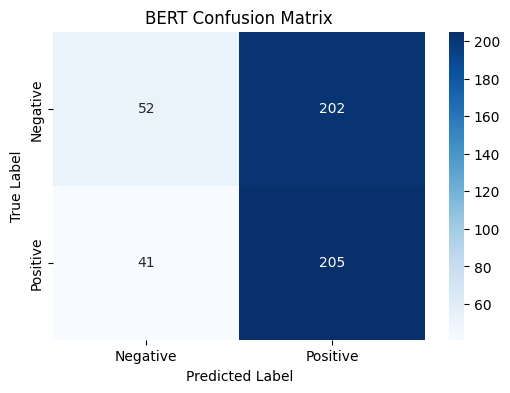

In [13]:
from transformers import AutoTokenizer
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Re-define the FIXED class so Colab completely forgets the old encode_plus version
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # The FIXED modern tokenizer call
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# 2. Re-create the validation dataset and loader with the fixed class
print("Re-initializing validation data with the fixed tokenizer...")
val_dataset = IMDBDataset(val_texts, val_labels, tokenizer)
val_loader = DataLoader(val_dataset, batch_size=16)

# 3. --- Task 6: Model Evaluation ---[cite: 4]
print("Evaluating the fine-tuned BERT model on the Validation Set...")
model.eval() # Switch model from training mode to evaluation mode

true_labels = []
predictions = []

# torch.no_grad() disables gradient calculation to save memory and speed up evaluation
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        outputs = model(input_ids, attention_mask=attention_mask)

        # Get the predicted classes (the highest probability score)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        true_labels.extend(labels.cpu().numpy())
        predictions.extend(preds)

# Calculate all required classification metrics[cite: 4]
acc = accuracy_score(true_labels, predictions)
prec = precision_score(true_labels, predictions)
rec = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

print("\n--- Evaluation Metrics ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Generate and plot the Confusion Matrix[cite: 4]
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('BERT Confusion Matrix')
plt.show()